<a href="https://colab.research.google.com/github/puteriazli/SpectroGenre-machine-learning-pipeline-for-music-genre-recognition/blob/main/music_genre_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1️⃣ | IMPORT LIBRARIES

In [ ]:
!pip install pandas numpy opendatasets seaborn matplotlib scikit-learn librosa xgboost tqdm ipython

In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import librosa
import librosa.display
import IPython.display as ipd
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ML Models
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier, XGBRFClassifier

# Utilities
import opendatasets as od
from tqdm import tqdm

warnings.filterwarnings('ignore')

# 2️⃣ | LOAD DATA

In [2]:
print("📥 Mengunduh dataset dari Kaggle...")
od.download("https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification")

df_path = './gtzan-dataset-music-genre-classification/Data/'
main_folder = f'{df_path}genres_original/'
print("Daftar Genre:", list(os.listdir(main_folder)))

Daftar Genre: ['blues', 'hiphop', 'disco', 'pop', 'classical', 'metal', 'rock', 'jazz', 'country', 'reggae']


# 3️⃣ | EXPLORE AUDIO DATA (EDA & VISUALIZATION)

In [8]:
print("\n🔍 Mengeksplorasi Data Audio (Contoh: Jazz)...")
sample_path = f'{main_folder}jazz/jazz.00028.wav'
y, sr = librosa.load(sample_path)

print('y shape:', np.shape(y))
print('Sample Rate (KHz):', sr)
print('Durasi Audio (detik):', len(y)/sr)


🔍 Mengeksplorasi Data Audio (Contoh: Jazz)...
y shape: (661794,)
Sample Rate (KHz): 22050
Durasi Audio (detik): 30.013333333333332


In [9]:
audio_file, _ = librosa.effects.trim(y)

### 1: Sound Waves

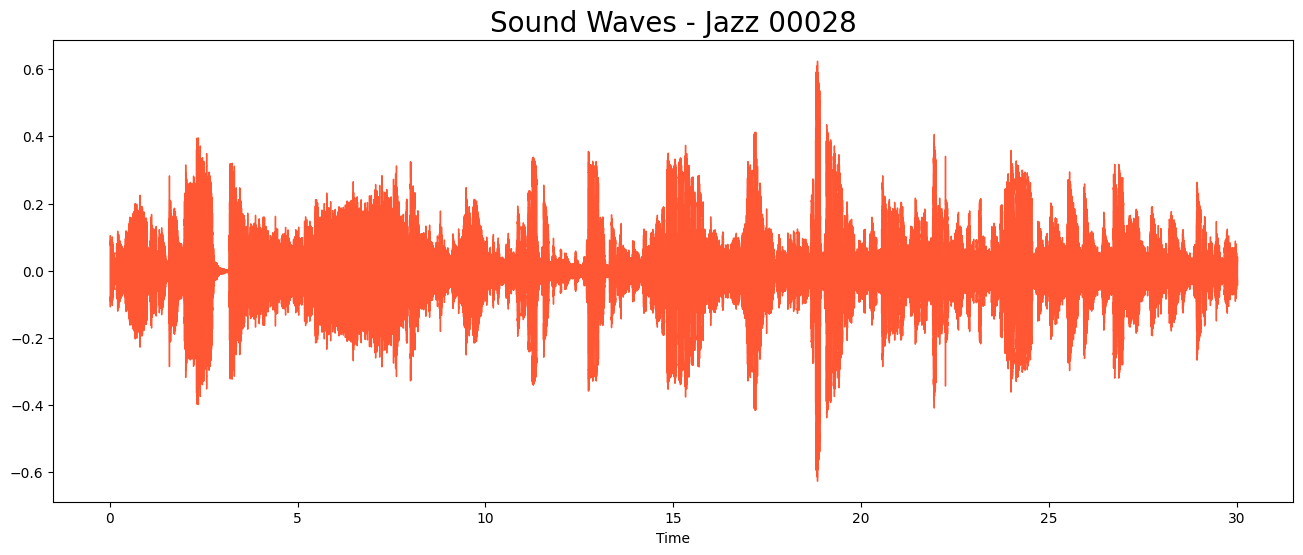

In [10]:
plt.figure(figsize=(16, 6))
librosa.display.waveshow(y=audio_file, sr=sr, color="#FF5733")
plt.title("Sound Waves - Jazz 00028", fontsize=20)
plt.show()

### 2: Fourier Transform (Spectrogram)

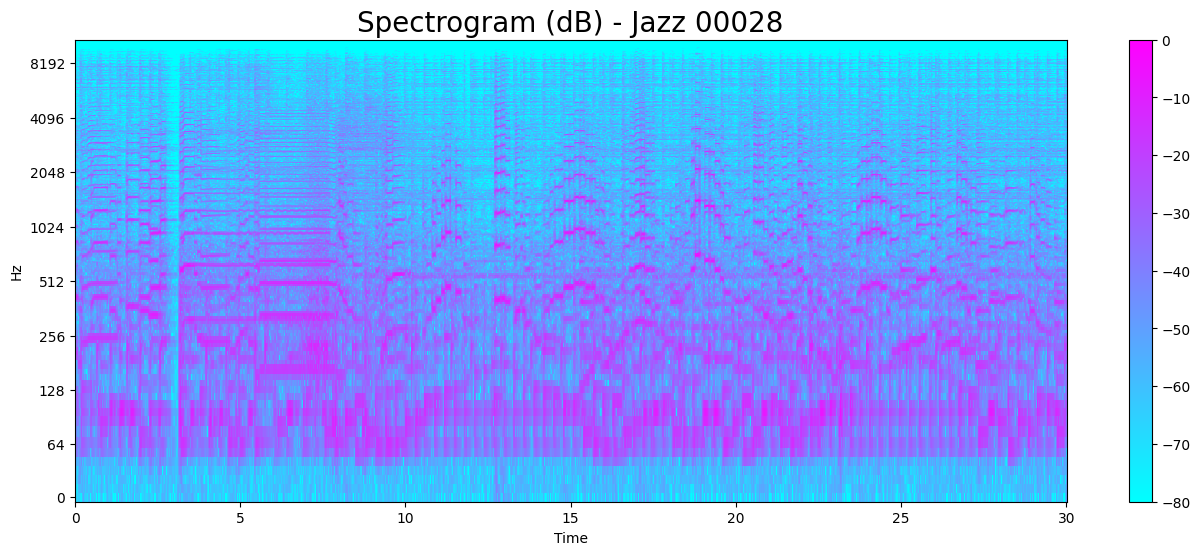

In [11]:
n_fft = 2048
hop_length = 512
D = np.abs(librosa.stft(audio_file, n_fft=n_fft, hop_length=hop_length))

DB = librosa.amplitude_to_db(D, ref=np.max)
plt.figure(figsize=(16, 6))
librosa.display.specshow(DB, sr=sr, hop_length=hop_length, x_axis='time', y_axis='log', cmap='cool')
plt.colorbar()
plt.title("Spectrogram (dB) - Jazz 00028", fontsize=20)
plt.show()

### 3: Mel Spectrogram (Contoh: Disco)

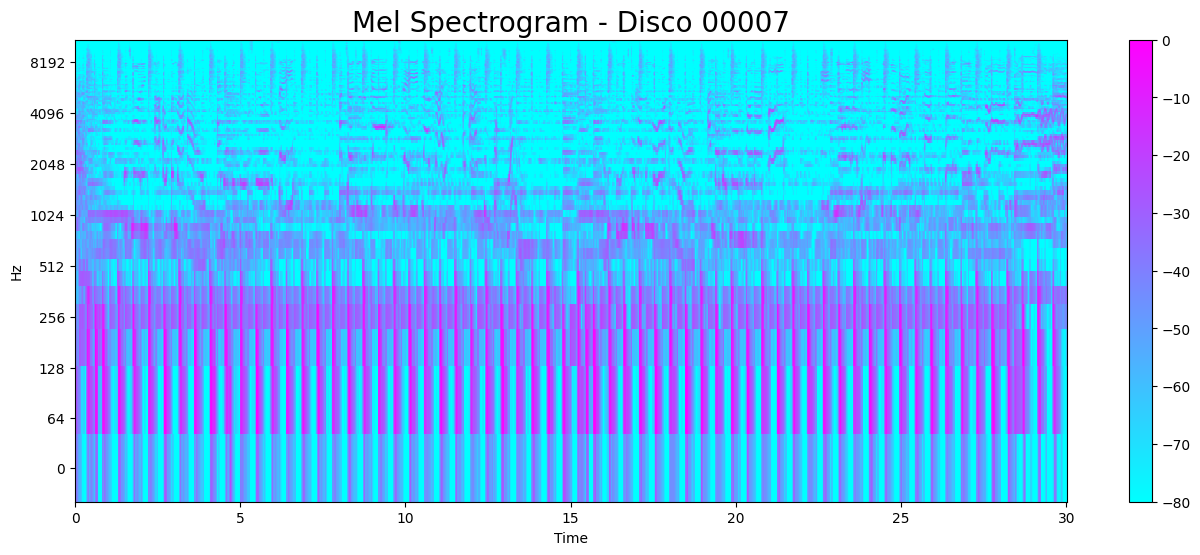

In [12]:
y_disco, _ = librosa.load(f'{main_folder}disco/disco.00007.wav')
y_disco, _ = librosa.effects.trim(y_disco)

S = librosa.feature.melspectrogram(y=y_disco, sr=sr)
S_DB = librosa.amplitude_to_db(S, ref=np.max)
plt.figure(figsize=(16, 6))
librosa.display.specshow(S_DB, sr=sr, hop_length=hop_length, x_axis='time', y_axis='log', cmap='cool')
plt.colorbar()
plt.title("Mel Spectrogram - Disco 00007", fontsize=20)
plt.show()

# 4️⃣ | AUDIO FEATURE EXTRACTION (IMPROVED WITH MFCC)

In [13]:
print("\n⚙️ Memulai Ekstraksi Fitur (Memproses seluruh audio)...")

def extract_audio_features(y, sr):
    zcr = librosa.feature.zero_crossing_rate(y=y)
    spec_cent = librosa.feature.spectral_centroid(y=y, sr=sr)
    spec_bw = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    spec_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    rmse = librosa.feature.rms(y=y)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)

    features = {
        'ZCR_mean': zcr.mean(), 'ZCR_var': zcr.var(),
        'spectral_centroid_mean': spec_cent.mean(), 'spectral_centroid_var': spec_cent.var(),
        'spectral_bandwidth_mean': spec_bw.mean(), 'spectral_bandwidth_var': spec_bw.var(),
        'spectral_rolloff_mean': spec_rolloff.mean(), 'spectral_rolloff_var': spec_rolloff.var(),
        'chroma_stft_mean': chroma.mean(), 'chroma_stft_var': chroma.var(),
        'rmse_mean': rmse.mean(), 'rmse_var': rmse.var(),
    }

    for i in range(1, 21):
        features[f'mfcc{i}_mean'] = mfcc[i-1].mean()
        features[f'mfcc{i}_var'] = mfcc[i-1].var()

    return features

all_features = []
genres = [d for d in os.listdir(main_folder) if os.path.isdir(os.path.join(main_folder, d))]

for genre in tqdm(genres, desc="Ekstraksi Fitur"):
    genre_path = os.path.join(main_folder, genre)
    for audio_file in os.listdir(genre_path):
        audio_path = os.path.join(genre_path, audio_file)
        if os.path.isfile(audio_path):
            try:
                y, sr = librosa.load(audio_path, duration=30)
                features = extract_audio_features(y, sr)
                features['File_Name'] = audio_file
                features['Label'] = genre
                all_features.append(features)
            except Exception as e:
                pass

df_features = pd.DataFrame(all_features)
cols = ['File_Name', 'Label'] + [c for c in df_features.columns if c not in ['File_Name', 'Label']]
df_features = df_features[cols]

csv_filename = "audio_features_improved.csv"
df_features.to_csv(csv_filename, index=False)
print(f"✅ Ekstraksi selesai. Tersimpan di {csv_filename}\n")


⚙️ Memulai Ekstraksi Fitur (Memproses seluruh audio)...


Ekstraksi Fitur: 100%|██████████| 10/10 [05:40<00:00, 34.03s/it]

✅ Ekstraksi selesai. Tersimpan di audio_features_improved.csv



# 5️⃣ | MODEL CLASSIFICATION

In [30]:
print("🤖 Mempersiapkan Data untuk Machine Learning...")
data = pd.read_csv(csv_filename)

🤖 Mempersiapkan Data untuk Machine Learning...


In [31]:
X = data.drop(columns=['Label', 'File_Name'])
y = data['Label']

In [32]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.15, random_state=42, stratify=y_encoded)

In [34]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1765, random_state=42, stratify=y_train)

In [35]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Jumlah Data - Latih: {len(X_train)} | Validasi: {len(X_val)} | Uji: {len(X_test)}\n")

Jumlah Data - Latih: 699 | Validasi: 150 | Uji: 150



In [36]:
model_results = {}

def model_assess(model, title="Default"):
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)

    print(f'Accuracy {title:25} : {round(acc * 100, 2)}%')

    model_results[title] = {
        'model': model,
        'accuracy': acc,
        'preds': preds
    }
    return model

print("🚀 Menguji Berbagai Model Machine Learning:\n")

🚀 Menguji Berbagai Model Machine Learning:



In [37]:
# Naive Bayes
nb = GaussianNB()
model_assess(nb, "Naive Bayes")

# Stochastic Gradient Descent
sgd = SGDClassifier(max_iter=5000, random_state=0)
model_assess(sgd, "Stochastic Gradient Descent")

# KNN
knn = KNeighborsClassifier(n_neighbors=19)
model_assess(knn, "KNN")

# Decision Tree
tree = DecisionTreeClassifier()
model_assess(tree, "Decision Tree")

# Random Forest
rforest = RandomForestClassifier(n_estimators=1000, max_depth=10, random_state=0)
model_assess(rforest, "Random Forest")

# Support Vector Machine
svm = SVC(decision_function_shape="ovo")
model_assess(svm, "Support Vector Machine")

# Logistic Regression
lg = LogisticRegression(random_state=0, solver='lbfgs', multi_class='multinomial', max_iter=1000)
model_assess(lg, "Logistic Regression")

# Neural Nets
nn = MLPClassifier(solver='adam', alpha=1e-5, hidden_layer_sizes=(512, 128), random_state=1, max_iter=500)
model_assess(nn, "Neural Nets")

# XGBoost
xgb = XGBClassifier(n_estimators=1000, learning_rate=0.05, random_state=0)
model_assess(xgb, "XGBoost Classifier")

# XGBoost Random Forest
xgbrf = XGBRFClassifier(objective='multi:softmax', random_state=0)
model_assess(xgbrf, "XGBoost RF Classifier")

Accuracy Naive Bayes               : 50.67%
Accuracy Stochastic Gradient Descent : 63.33%
Accuracy KNN                       : 58.0%
Accuracy Decision Tree             : 46.67%
Accuracy Random Forest             : 64.0%
Accuracy Support Vector Machine    : 67.33%
Accuracy Logistic Regression       : 68.0%
Accuracy Neural Nets               : 73.33%
Accuracy XGBoost Classifier        : 69.33%
Accuracy XGBoost RF Classifier     : 60.0%


XGBRFClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bytree=None, device=None,
                early_stopping_rounds=None, enable_categorical=False,
                eval_metric=None, feature_types=None, feature_weights=None,
                gamma=None, grow_policy=None, importance_type=None,
                interaction_constraints=None, max_bin=None,
                max_cat_threshold=None, max_cat_to_onehot=None,
                max_delta_step=None, max_depth=None, max_leaves=None,
                min_child_weight=None, missing=nan, monotone_constraints=None,
                multi_strategy=None, n_estimators=None, n_jobs=None,
                num_parallel_tree=None, objective='multi:softmax',
                random_state=0, ...)

In [38]:
best_model_name = max(model_results, key=lambda k: model_results[k]['accuracy'])
best_model = model_results[best_model_name]['model']
test_preds = model_results[best_model_name]['preds']
best_acc = model_results[best_model_name]['accuracy']

print("-" * 50)
print(f"🏆 MODEL TERBAIK: {best_model_name}")
print(f"🌟 AKURASI: {round(best_acc * 100, 2)}%")
print("-" * 50)

--------------------------------------------------
🏆 MODEL TERBAIK: Neural Nets
🌟 AKURASI: 73.33%
--------------------------------------------------


# 6️⃣ | FINAL EVALUATION & CONFUSION MATRIX

In [39]:
sns.set_theme(style="whitegrid", palette="muted")

### 1: CONFUSION MATRIX

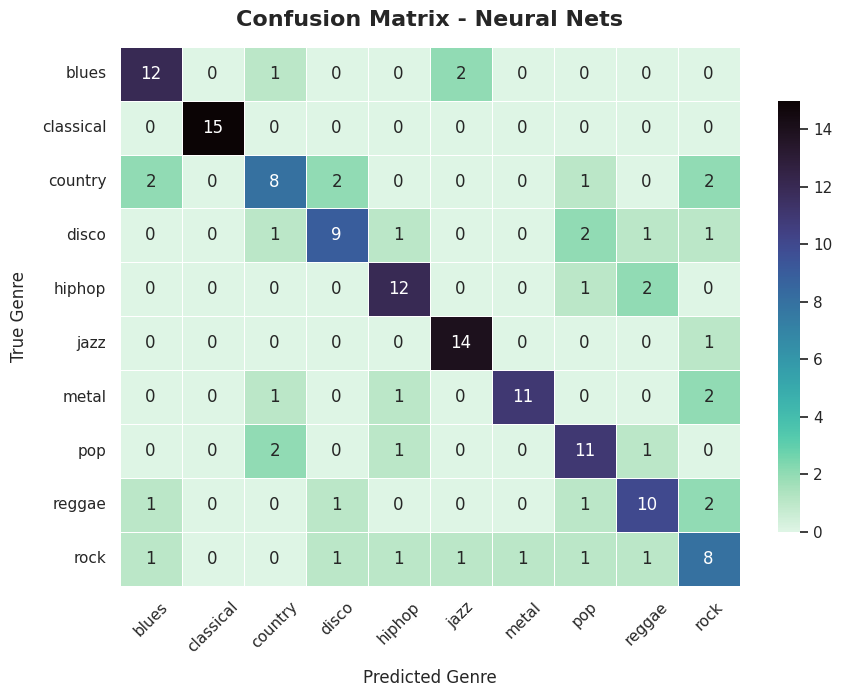

In [40]:
confusion_matr = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matr, cmap="mako_r", annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=.5, cbar_kws={"shrink": .8})
plt.title(f"Confusion Matrix - {best_model_name}", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Predicted Genre", fontsize=12, labelpad=10)
plt.ylabel("True Genre", fontsize=12, labelpad=10)
plt.xticks(rotation=45)
plt.show()

### 2: CLASSIFICATION REPORT HEATMAP

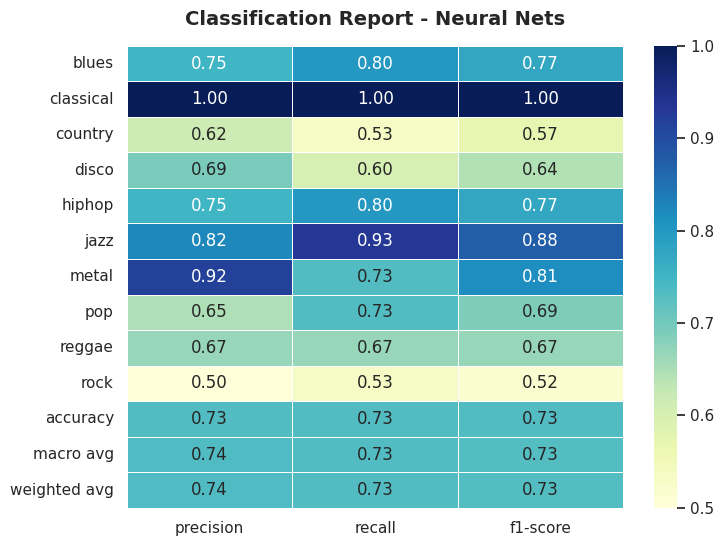

In [41]:
clf_report = classification_report(y_test, test_preds, target_names=le.classes_, output_dict=True)
df_report = pd.DataFrame(clf_report).iloc[:-1, :].T

plt.figure(figsize=(8, 6))
sns.heatmap(df_report, annot=True, cmap="YlGnBu", fmt=".2f", vmin=0.5, vmax=1.0, linewidths=.5)
plt.title(f"Classification Report - {best_model_name}", fontsize=14, fontweight='bold', pad=15)
plt.show()

### 3: FEATURE IMPORTANCE

In [42]:
if hasattr(best_model, 'feature_importances_'):
    feature_importances = best_model.feature_importances_

    top_idx = np.argsort(feature_importances)[-15:]
    top_features = X.columns[top_idx]
    top_scores = feature_importances[top_idx]

    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_scores, y=top_features, palette="viridis")
    plt.title(f"Top 15 Fitur Audio Paling Penting ({best_model_name})", fontsize=14, fontweight='bold')
    plt.xlabel("Tingkat Kepentingan (Importance Score)", fontsize=12)
    plt.ylabel("Nama Fitur", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print(f"\n⚠️ Catatan: Model '{best_model_name}' tidak mendukung visualisasi Feature Importance.")
    print("Grafik Feature Importance hanya bisa digambar untuk algoritma berbasis Tree (seperti Random Forest atau XGBoost).")


⚠️ Catatan: Model 'Neural Nets' tidak mendukung visualisasi Feature Importance.
Grafik Feature Importance hanya bisa digambar untuk algoritma berbasis Tree (seperti Random Forest atau XGBoost).
